In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

In [ ]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def create_model(lr):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
learning_rates = [0.1,0.01,0.001]

results=[]

for lr in learning_rates:

    model=create_model(lr)

    model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    results.append([lr,acc])

df=pd.DataFrame(results,
                columns=["Learning Rate","Accuracy"])

print(df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0          0.100  1.000000
1          0.010  1.000000
2          0.001  0.966667


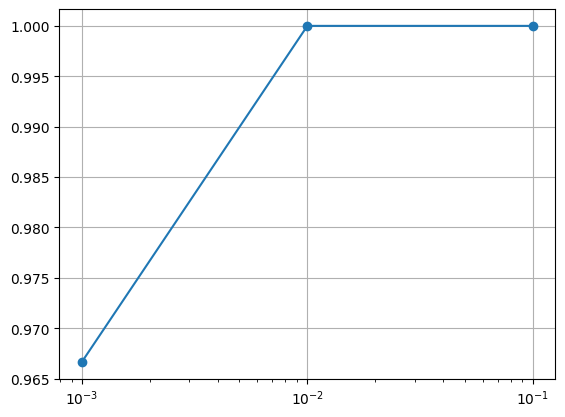

In [ ]:
plt.plot(df["Learning Rate"],
         df["Accuracy"],
         marker="o")

plt.xscale("log")
plt.grid(True)
plt.show()

In [ ]:
epochs_list=[10,30,50]

results=[]

for ep in epochs_list:

    model=create_model(0.001)

    history=model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=16,
        verbose=0
    )

    loss,acc=model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    results.append([ep,acc])

edf=pd.DataFrame(results,
                 columns=["Epochs","Accuracy"])

print(edf)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0      10  0.633333
1      30  0.733333
2      50  0.866667


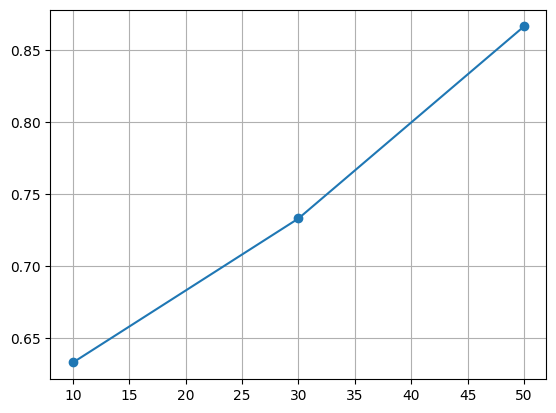

In [ ]:
plt.plot(edf["Epochs"],
         edf["Accuracy"],
         marker="o")

plt.grid(True)
plt.show()

In [ ]:
model=create_model(0.001)

history=model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5521 - loss: 1.1460 - val_accuracy: 0.3333 - val_loss: 1.2753
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5521 - loss: 1.1133 - val_accuracy: 0.3333 - val_loss: 1.2290
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5521 - loss: 1.0836 - val_accuracy: 0.3333 - val_loss: 1.1874
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5729 - loss: 1.0547 - val_accuracy: 0.3333 - val_loss: 1.1531
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5833 - loss: 1.0292 - val_accuracy: 0.3333 - val_loss: 1.1194
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6042 - loss: 1.0029 - val_accuracy: 0.3333 - val_loss: 1.0882
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6042 - loss: 0.9767 - val_accuracy: 0.3333 - val_loss: 1.0556
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6146 - loss: 0.9507 - val_accuracy: 0.3750 - val_loss: 1.0236
Epoch 9/50


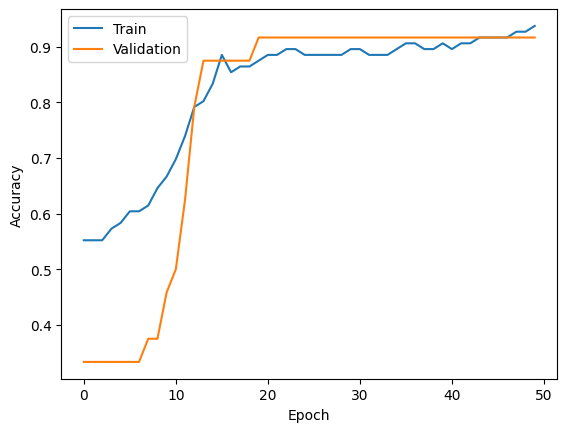

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

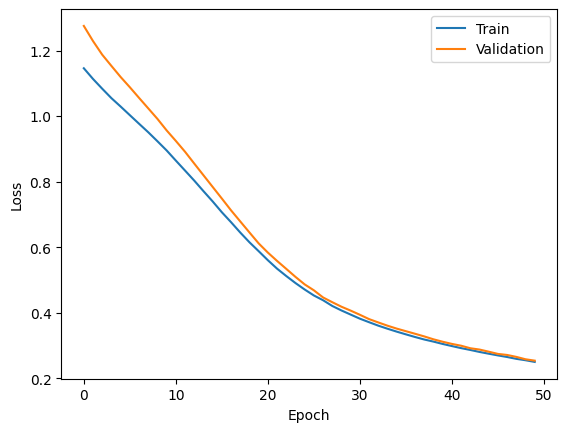

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
loss,accuracy=model.evaluate(
    X_test,
    y_test
)

print("Loss:",loss)

print("Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9667 - loss: 0.1840
Loss: 0.18404124677181244
Accuracy: 0.9666666388511658
